In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.utils import shuffle
from sklearn.metrics import pairwise_distances
from collections import Counter, defaultdict
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from scipy.stats import gaussian_kde

Loading MNIST...
Building representation phi: X -> Z using PCA...
Running incremental operational manifold coverage experiment...

Summary:
      n  classes_observed  separable_fraction  median_margin  p10_margin  \
0    50                10              0.5014       0.004323   -1.575508   
1   100                10              0.6014       0.392207   -1.247945   
2   200                10              0.7096       0.779483   -0.882949   
3   500                10              0.8064       1.181403   -0.511209   
4  1000                10              0.8734       1.646376   -0.161136   
5  2000                10              0.9270       2.680104    0.205233   
6  5000                10              1.0000       6.561585    4.947069   

   p90_margin  mean_d_in  mean_d_out  mean_class_radius  mean_class_radius_p95  
0    2.083725   7.739783    7.931713           5.946253               6.889261  
1    2.625893   7.100329    7.719921           6.256337               7.652597  
2    3.4

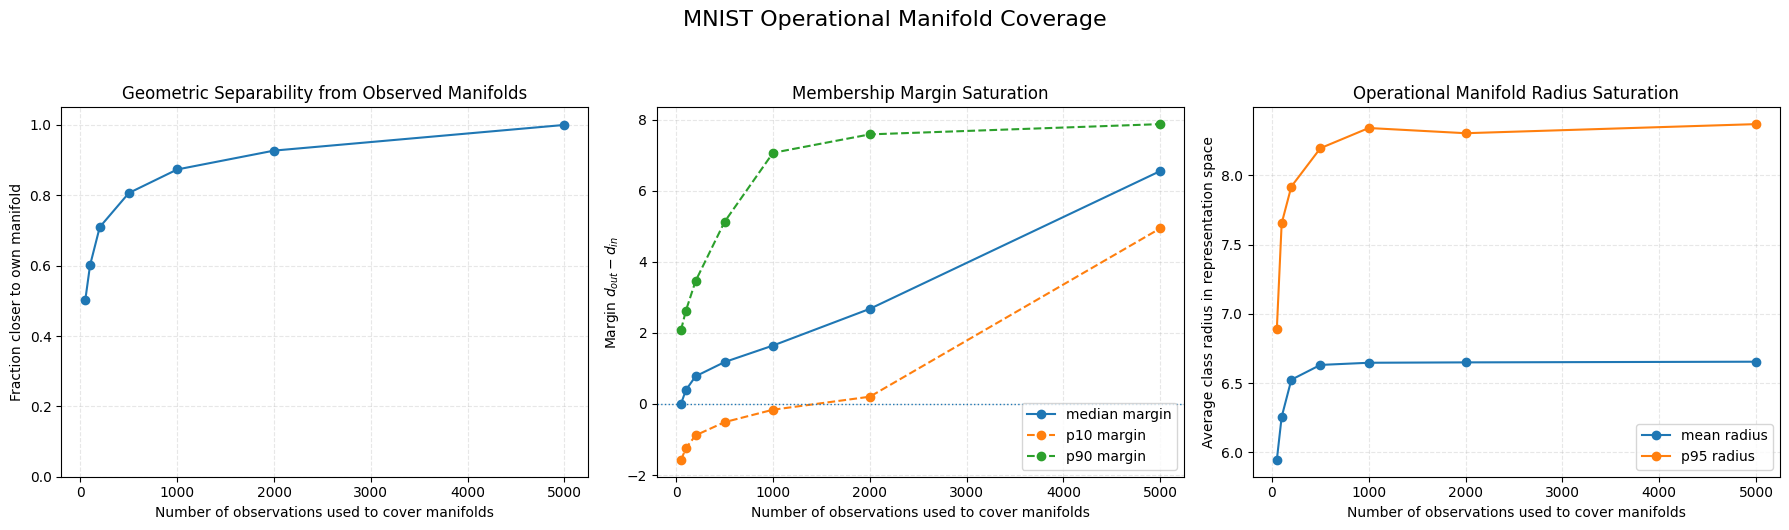

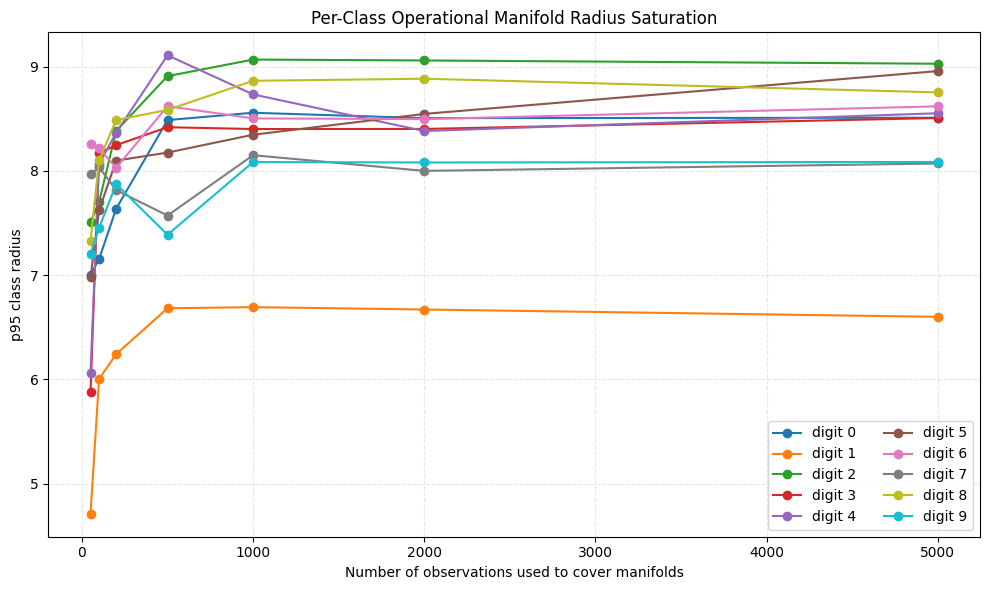

In [2]:
# ------------------------------------------------------------
# 1. Load MNIST
# ------------------------------------------------------------
print("Loading MNIST...")
mnist = fetch_openml("mnist_784", version=1, parser="auto")

X_raw, y = shuffle(mnist.data, mnist.target, random_state=42)
X_raw = np.asarray(X_raw[:5000], dtype=np.float32) / 255.0
y = np.asarray(y[:5000], dtype=int)

# ------------------------------------------------------------
# 2. Representation phi: raw -> PCA space
# ------------------------------------------------------------
print("Building representation phi: X -> Z using PCA...")
pca = PCA(n_components=50, random_state=42)
Z = pca.fit_transform(X_raw)

# Optional but useful: standardize PCA coordinates for distance stability
Z = StandardScaler().fit_transform(Z)

classes = np.unique(y)
sample_sizes = [50, 100, 200, 500, 1000, 2000, 5000]

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def compute_class_centroids(Z_subset, y_subset, classes):
    centroids = {}
    for c in classes:
        mask = y_subset == c
        if np.sum(mask) > 0:
            centroids[c] = Z_subset[mask].mean(axis=0)
    return centroids


def distance_to_class_set(z, Z_class):
    """
    Distance from one point z to an observed class manifold.
    Here we use nearest-neighbor distance to the observed support.
    """
    if len(Z_class) == 0:
        return np.inf
    return np.min(np.linalg.norm(Z_class - z, axis=1))


def class_radius_p95(Z_class):
    """
    Robust class radius: p95 distance to class centroid.
    Better than max radius because MNIST has ambiguous/outlier digits.
    """
    if len(Z_class) < 2:
        return np.nan
    centroid = Z_class.mean(axis=0)
    d = np.linalg.norm(Z_class - centroid, axis=1)
    return np.percentile(d, 95)


def class_radius_mean(Z_class):
    if len(Z_class) < 2:
        return np.nan
    centroid = Z_class.mean(axis=0)
    d = np.linalg.norm(Z_class - centroid, axis=1)
    return np.mean(d)


def evaluate_prefix(Z, y, n, classes):
    """
    Use first n observations as the currently observed operational manifolds.

    For every point in the full dataset, compute:
    - distance to its own observed class manifold
    - distance to closest competing observed class manifold
    - geometric margin = d_out - d_in

    If margin > 0, the point is geometrically separable under current manifold memory.
    """
    Z_seen = Z[:n]
    y_seen = y[:n]

    # observed support per class
    class_sets = {
        c: Z_seen[y_seen == c]
        for c in classes
    }

    margins = []
    d_in_list = []
    d_out_list = []
    separable_flags = []

    for zi, yi in zip(Z, y):
        own_set = class_sets[yi]
        d_in = distance_to_class_set(zi, own_set)

        d_out = np.inf
        for c in classes:
            if c == yi:
                continue
            d_c = distance_to_class_set(zi, class_sets[c])
            if d_c < d_out:
                d_out = d_c

        margin = d_out - d_in
        separable = margin > 0

        d_in_list.append(d_in)
        d_out_list.append(d_out)
        margins.append(margin)
        separable_flags.append(separable)

    d_in_arr = np.array(d_in_list)
    d_out_arr = np.array(d_out_list)
    margins_arr = np.array(margins)
    separable_arr = np.array(separable_flags)

    # Class radii among observed samples
    radius_mean_by_class = {}
    radius_p95_by_class = {}

    for c in classes:
        Z_c = class_sets[c]
        radius_mean_by_class[c] = class_radius_mean(Z_c)
        radius_p95_by_class[c] = class_radius_p95(Z_c)

    row = {
        "n": n,
        "classes_observed": sum(len(class_sets[c]) > 0 for c in classes),
        "separable_fraction": np.mean(separable_arr),
        "median_margin": np.median(margins_arr[np.isfinite(margins_arr)]),
        "p10_margin": np.percentile(margins_arr[np.isfinite(margins_arr)], 10),
        "p90_margin": np.percentile(margins_arr[np.isfinite(margins_arr)], 90),
        "mean_d_in": np.mean(d_in_arr[np.isfinite(d_in_arr)]),
        "mean_d_out": np.mean(d_out_arr[np.isfinite(d_out_arr)]),
        "mean_class_radius": np.nanmean(list(radius_mean_by_class.values())),
        "mean_class_radius_p95": np.nanmean(list(radius_p95_by_class.values())),
    }

    return row, radius_mean_by_class, radius_p95_by_class


# ------------------------------------------------------------
# 3. Run incremental manifold coverage experiment
# ------------------------------------------------------------
print("Running incremental operational manifold coverage experiment...")

rows = []
radius_mean_records = []
radius_p95_records = []

for n in sample_sizes:
    row, r_mean_class, r_p95_class = evaluate_prefix(Z, y, n, classes)
    rows.append(row)

    for c in classes:
        radius_mean_records.append({
            "n": n,
            "class": c,
            "radius_mean": r_mean_class[c]
        })
        radius_p95_records.append({
            "n": n,
            "class": c,
            "radius_p95": r_p95_class[c]
        })

df = pd.DataFrame(rows)
df_r_mean = pd.DataFrame(radius_mean_records)
df_r_p95 = pd.DataFrame(radius_p95_records)

print("\nSummary:")
print(df)

# ------------------------------------------------------------
# 4. Plot main saturation curves
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A. Fraction geometrically separable
axes[0].plot(df["n"], df["separable_fraction"], marker="o")
axes[0].set_title("Geometric Separability from Observed Manifolds")
axes[0].set_xlabel("Number of observations used to cover manifolds")
axes[0].set_ylabel("Fraction closer to own manifold")
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, linestyle="--", alpha=0.3)

# B. Margin saturation
axes[1].plot(df["n"], df["median_margin"], marker="o", label="median margin")
axes[1].plot(df["n"], df["p10_margin"], marker="o", linestyle="--", label="p10 margin")
axes[1].plot(df["n"], df["p90_margin"], marker="o", linestyle="--", label="p90 margin")
axes[1].axhline(0, linestyle=":", linewidth=1)
axes[1].set_title("Membership Margin Saturation")
axes[1].set_xlabel("Number of observations used to cover manifolds")
axes[1].set_ylabel(r"Margin $d_{out} - d_{in}$")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.3)

# C. Mean class radius saturation
axes[2].plot(df["n"], df["mean_class_radius"], marker="o", label="mean radius")
axes[2].plot(df["n"], df["mean_class_radius_p95"], marker="o", label="p95 radius")
axes[2].set_title("Operational Manifold Radius Saturation")
axes[2].set_xlabel("Number of observations used to cover manifolds")
axes[2].set_ylabel("Average class radius in representation space")
axes[2].legend()
axes[2].grid(True, linestyle="--", alpha=0.3)

plt.suptitle("MNIST Operational Manifold Coverage", fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig("mnist_operational_manifold_coverage.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 5. Plot radius saturation per digit
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

for c in classes:
    sub = df_r_p95[df_r_p95["class"] == c]
    plt.plot(sub["n"], sub["radius_p95"], marker="o", label=f"digit {c}")

plt.title("Per-Class Operational Manifold Radius Saturation")
plt.xlabel("Number of observations used to cover manifolds")
plt.ylabel("p95 class radius")
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.savefig("mnist_per_class_radius_saturation.png", dpi=300, bbox_inches="tight")
plt.show()

In [3]:
Z_vis = Z

Z_vis = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    init="pca",
    learning_rate="auto"
).fit_transform(Z)

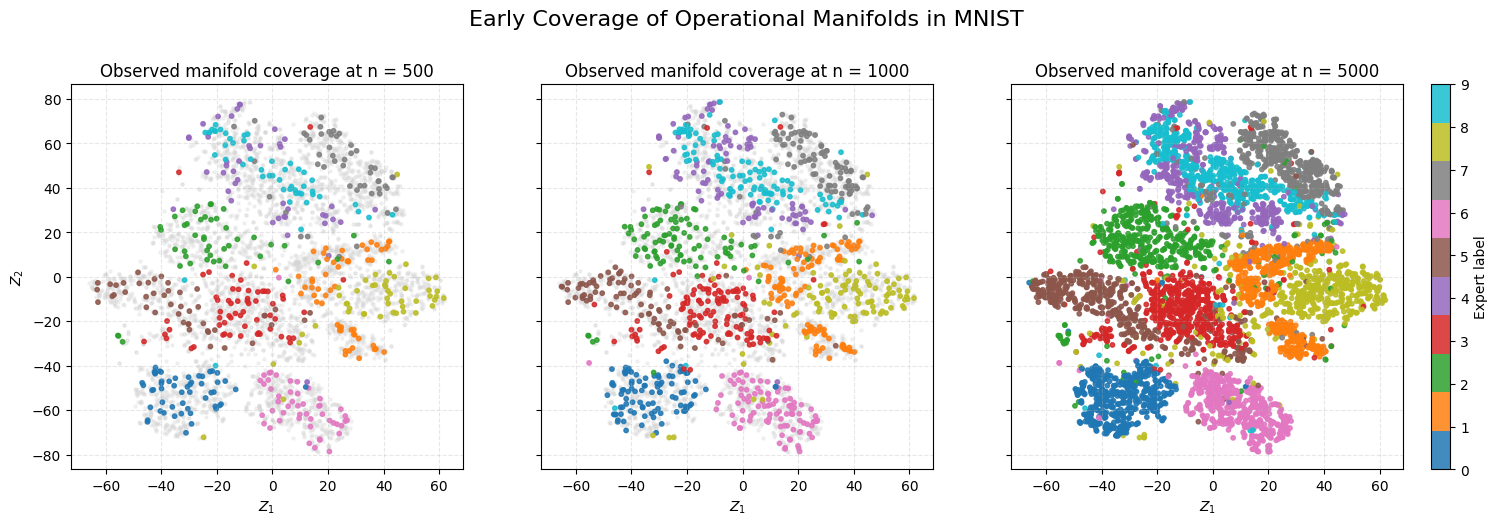

In [4]:
# Assumes:
# Z = representation, e.g. PCA/t-SNE coordinates for all 5000 points
# y = expert labels
# If Z has 50D PCA, use Z_vis from t-SNE only for visualization.
# Here I assume Z_vis is 2D.

prefix_sizes = [500, 1000, 5000]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for ax, n in zip(axes, prefix_sizes):
    # Full domain in background
    ax.scatter(
        Z_vis[:, 0],
        Z_vis[:, 1],
        c="lightgray",
        s=5,
        alpha=0.25,
        label="Full domain"
    )

    # Observed prefix
    sc = ax.scatter(
        Z_vis[:n, 0],
        Z_vis[:n, 1],
        c=y[:n],
        cmap="tab10",
        s=10,
        alpha=0.85
    )

    ax.set_title(f"Observed manifold coverage at n = {n}")
    ax.set_xlabel(r"$Z_1$")
    ax.grid(True, linestyle="--", alpha=0.3)

axes[0].set_ylabel(r"$Z_2$")

cbar = plt.colorbar(sc, ax=axes, ticks=range(10), fraction=0.025, pad=0.02)
cbar.set_label("Expert label")

plt.suptitle(
    "Early Coverage of Operational Manifolds in MNIST",
    fontsize=16,
    y=1.03
)

plt.savefig("mnist_early_vs_full_manifold_coverage.png", dpi=300, bbox_inches="tight")
plt.show()

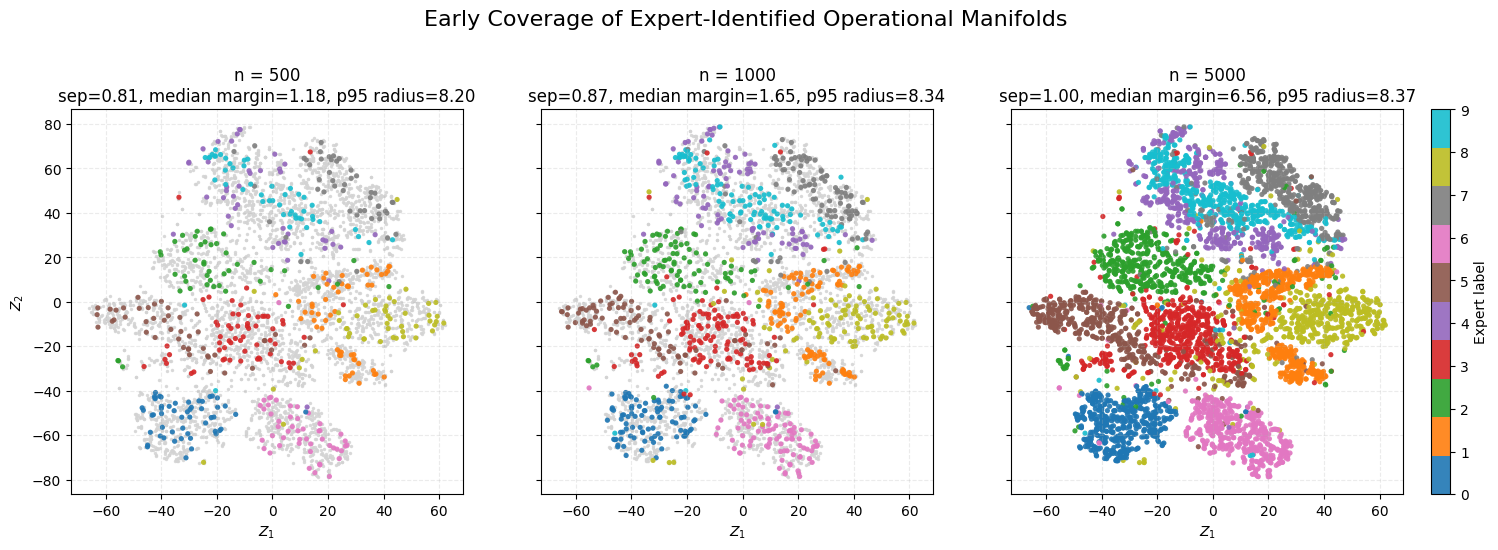

In [5]:

# Assumes:
# Z_vis: 2D visualization embedding, shape (N, 2)
# y: labels, shape (N,)
# Example:
# Z_vis = Z if Z is already 2D t-SNE
# y = y_expert

prefix_sizes = [500, 1000, 5000]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for ax, n in zip(axes, prefix_sizes):
    ax.scatter(
        Z_vis[:, 0], Z_vis[:, 1],
        c="lightgray", s=6, alpha=0.88,
        linewidths=0
    )

    sc = ax.scatter(
        Z_vis[:n, 0], Z_vis[:n, 1],
        c=y[:n], cmap="tab10",
        s=14, alpha=0.9,
        linewidths=0
    )

    # Optional: pull metrics from df
    row = df[df["n"] == n].iloc[0]
    sep = row["separable_fraction"]
    margin = row["median_margin"]
    r95 = row["mean_class_radius_p95"]

    ax.set_title(
        f"n = {n}\n"
        f"sep={sep:.2f}, median margin={margin:.2f}, p95 radius={r95:.2f}",
        fontsize=12
    )
    ax.set_xlabel(r"$Z_1$")
    ax.grid(True, linestyle="--", alpha=0.25)

axes[0].set_ylabel(r"$Z_2$")

cbar = plt.colorbar(sc, ax=axes, ticks=range(10), fraction=0.025, pad=0.02)
cbar.set_label("Expert label")

plt.suptitle(
    "Early Coverage of Expert-Identified Operational Manifolds",
    fontsize=16,
    y=1.08
)

plt.savefig("mnist_early_coverage_clean.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
pip freeze > requirements.txt


Note: you may need to restart the kernel to use updated packages.
